In [26]:
import os
import sys
from functions.CIF_Functions import make_df_atomlist
import glob
import numpy as np
import pandas as pd

In [47]:
#               Predictions
###############################################
# select input files
filepaths= glob.glob('cif_files\\Predictions\\Complexes\\*tmtc[1-4]\\*.cif')
filepaths.extend(glob.glob('cif_files\\Predictions\\Complexes\\*_noptm\\*.cif'))
filepaths.extend(glob.glob('cif_files\\Predictions\\Complexes\\Auto_seed\\*[1-4]_auto\\*cif'))
filepaths.extend(glob.glob('cif_files\\Predictions\\Complexes\\Auto_seed\\*noptm_auto\\*cif'))


In [48]:
# put all predictions in a list as analysable dataframes
grouped_model_list = {}
atomlist = ["CA","N","C"]
for filepath in filepaths:
    df = make_df_atomlist(filepath,atomlist)
    # splitting filepaths to make readable names
    grouped_model_list[filepath.split("\\")[-1]] = df

#               Crystal
###############################################
XR_PATH = "cif_files\\Crystals\\7stz (1).cif"
xr_df = make_df_atomlist(XR_PATH,atomlist)

In [49]:
import json
filepaths_confidences= glob.glob('cif_files\\Predictions\\Complexes\\*tmtc[1-4]\\*confidences_*.json')
filepaths_confidences.extend(glob.glob('cif_files\\Predictions\\Complexes\\*noptm\\*confidences_*.json'))
filepaths_confidences.extend(glob.glob('cif_files\\Predictions\\Complexes\\Auto_seed\\*[1-4]_auto\\*confidences_*.json'))
filepaths_confidences.extend(glob.glob('cif_files\\Predictions\\Complexes\\Auto_seed\\*noptm_auto\\*confidences_*.json'))

# not PAE

Zink RMSD to expected residue "binding" site

In [50]:
from functions.CIF_Functions import make_df_full
from MDAnalysis.analysis.rms import rmsd

zinkrmsd = []
for path in filepaths:
    df = make_df_full(path)
    if "tmtc1" in path:
        zinkrmsd.append(rmsd(
            list(df[(df["label_seq_id"]=="220")&(df["label_asym_id"]=="B")&(df["label_atom_id"]=="CA")].values)[0][10:13],
            list(df[(df["label_comp_id"]=="ZN")].values)[0][10:13]))
    elif "tmtc2" in path:
        zinkrmsd.append(rmsd(
            list(df[(df["label_seq_id"]=="187")&(df["label_asym_id"]=="B")&(df["label_atom_id"]=="CA")].values)[0][10:13],
            list(df[(df["label_comp_id"]=="ZN")].values)[0][10:13]))
    elif "tmtc3" in path:
        zinkrmsd.append(rmsd(
            list(df[(df["label_seq_id"]=="303")&(df["label_asym_id"]=="B")&(df["label_atom_id"]=="CA")].values)[0][10:13],
            list(df[(df["label_comp_id"]=="ZN")].values)[0][10:13]))
    elif "tmtc4" in path:
        zinkrmsd.append(rmsd(
            list(df[(df["label_seq_id"]=="222")&(df["label_asym_id"]=="B")&(df["label_atom_id"]=="CA")].values)[0][10:13],
            list(df[(df["label_comp_id"]=="ZN")].values)[0][10:13]))

Fetching closest B chain-Atom to mannose binding residue  (for all mannoses)

In [43]:
man_d_df = pd.DataFrame()
for mannose in [126,204,206,314,316,318,422,424,426]:
    ls = []
    for path in filepaths:
        df = make_df_full(path)
        # get 126 coords
        xyz_126 = df[(df["label_seq_id"]==f"{mannose}")&(df["label_atom_id"]=="CA")&(df["label_asym_id"]=="A")][["Cartn_x","Cartn_y","Cartn_z"]].values[0]
        # get distances of closes B chain to closest bma
        enzyme = df[(df["label_asym_id"]=="B")][["Cartn_x","Cartn_y","Cartn_z"]].values
        ls.append(min([rmsd(xyz_126.astype(float),enzyme[i].astype(float)) for i in range(len(enzyme))]))

    man_d_df[f"d_to_{mannose}"] = ls

In [44]:
ls = []
for path in filepaths:
    df = make_df_full(path)
    a = df[(df["label_asym_id"]=="A")][["Cartn_x","Cartn_y","Cartn_z"]].values
    b = df[(df["label_asym_id"]=="B")][["Cartn_x","Cartn_y","Cartn_z"]].values
    ls.append(min([rmsd(b[:len(a)],a),rmsd(b[-len(a):],a)]))

## Big dataframe of all info

In [51]:

bigdf = pd.DataFrame({"enzyme":
                      [model[13:18] for model in grouped_model_list.keys()],
                      "model":
                      [model[-5] for model in grouped_model_list.keys()],
                      "plddt":
                      [np.average(list(grouped_model_list[model]["B_iso_or_equiv"].astype(float))) for model in grouped_model_list.keys()],
                      "mannosylated":
                      [True for _ in range(20)]+[False for _ in range(20)]+[True for _ in range(20)]+[False for _ in range(20)],
                      "seed":
                      [37 for _ in range(40)]+["auto" for _ in range(40)],
                      "iptm": 
                      [json.load(open(file))["iptm"] for file in filepaths_confidences],
                      "ptm":
                      [json.load(open(file))["ptm"] for file in filepaths_confidences],
                      "zinkRMSD":
                      zinkrmsd,
                      "A-B RMSD":
                      ls,
                      "fullname":
                      grouped_model_list.keys(),
                      })


In [52]:
bigbig_df = bigdf.join(man_d_df)
bigbig_df

,enzyme,model,plddt,mannosylated,seed,iptm,ptm,zinkRMSD,A-B RMSD,fullname,d_to_126,d_to_204,d_to_206,d_to_314,d_to_316,d_to_318,d_to_422,d_to_424,d_to_426
0,tmtc1,0,88.214494,True,37,0.28,0.47,17.862681,85.155961,fold_complex_tmtc1_model_0.cif,4.144330,14.158014,10.197174,8.539570,11.515374,13.156400,6.283568,5.095018,5.001271
1,tmtc1,1,88.430710,True,37,0.27,0.47,84.671460,62.108678,fold_complex_tmtc1_model_1.cif,4.399530,8.213763,7.284896,19.037940,21.921391,25.158004,26.925064,26.237109,26.282768
2,tmtc1,2,87.687611,True,37,0.27,0.48,17.857156,85.896233,fold_complex_tmtc1_model_2.cif,9.721226,6.274461,5.858767,19.730770,20.446456,22.066662,24.051720,23.807273,24.880974
3,tmtc1,3,88.497827,True,37,0.28,0.47,19.429389,91.934868,fold_complex_tmtc1_model_3.cif,11.017922,14.565470,11.703496,16.808941,15.631783,14.620201,5.261194,7.162960,8.562589
4,tmtc1,4,87.958469,True,37,0.27,0.48,18.274394,55.609018,fold_complex_tmtc1_model_4.cif,6.214953,8.400137,9.766837,7.725962,8.726123,10.434560,16.259455,14.257870,12.478342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,tmtc4,0,88.510259,False,auto,0.14,0.53,14.887019,77.044763,fold_complex_tmtc4_noptm_auto_model_0.cif,4.492552,9.606692,6.550498,12.206246,11.609633,11.159647,12.552459,14.701272,18.102291
76,tmtc4,1,88.438475,False,auto,0.14,0.53,73.920072,76.965346,fold_complex_tmtc4_noptm_auto_model_1.cif,2.533498,10.220356,7.136084,10.292988,11.062075,11.331648,14.568542,17.271513,20.913771
77,tmtc4,2,89.286716,False,auto,0.13,0.53,128.519921,138.684876,fold_complex_tmtc4_noptm_auto_model_2.cif,26.967800,18.009481,21.093860,44.277447,46.702365,49.660532,66.684555,68.680573,71.664378
78,tmtc4,3,89.571432,False,auto,0.13,0.53,15.749740,140.123489,fold_complex_tmtc4_noptm_auto_model_3.cif,28.086106,24.018380,27.571845,44.980976,48.568828,52.477520,71.997237,72.750205,74.629894


[Paper](https://www.pnas.org/doi/10.1073/pnas.1708319114) about TMTC1-3 involvement in B-G strands
[Another](https://www.mcponline.org/article/S1535-9476%2824%2900086-0/fulltext) paper about the TMTC1 structure-workings

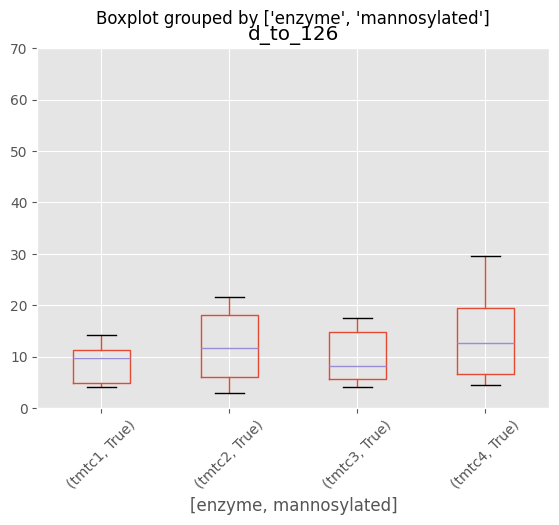

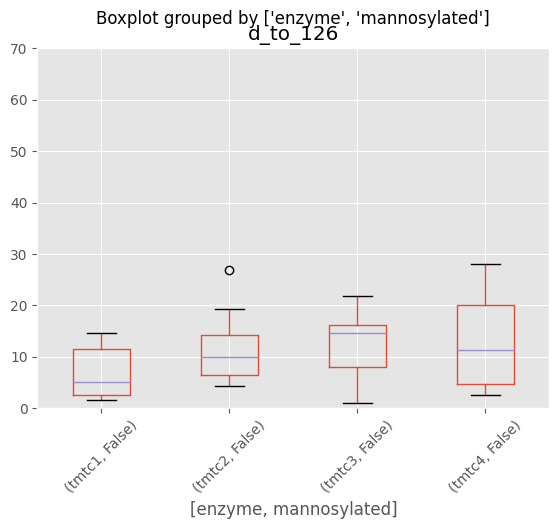

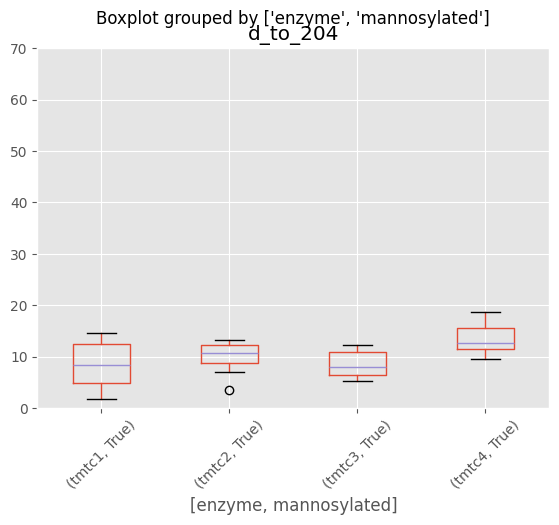

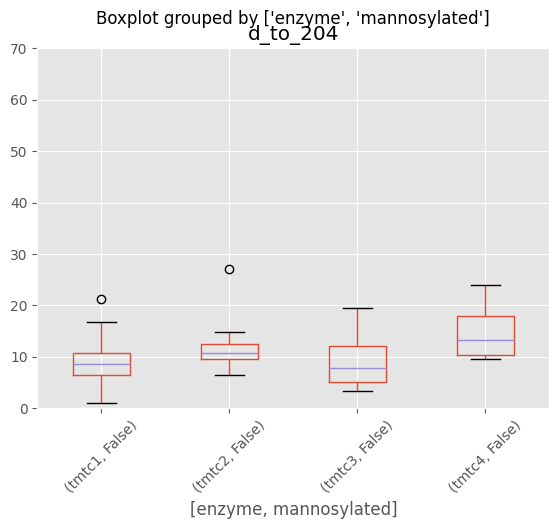

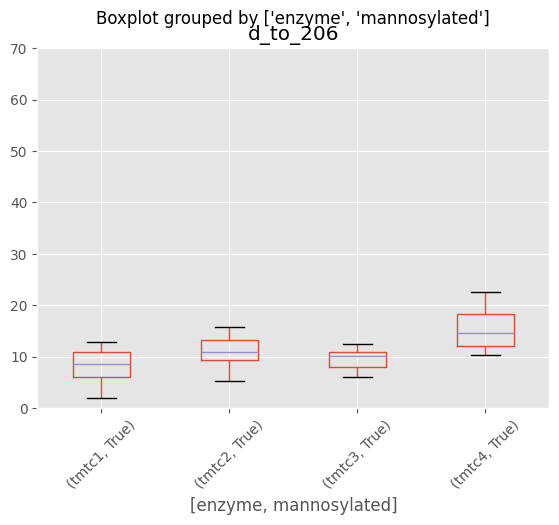

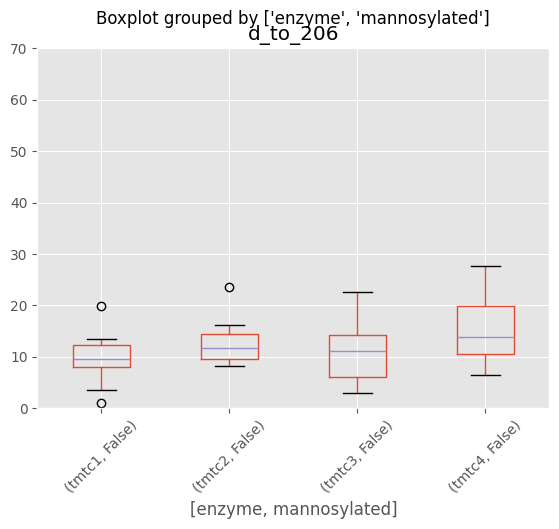

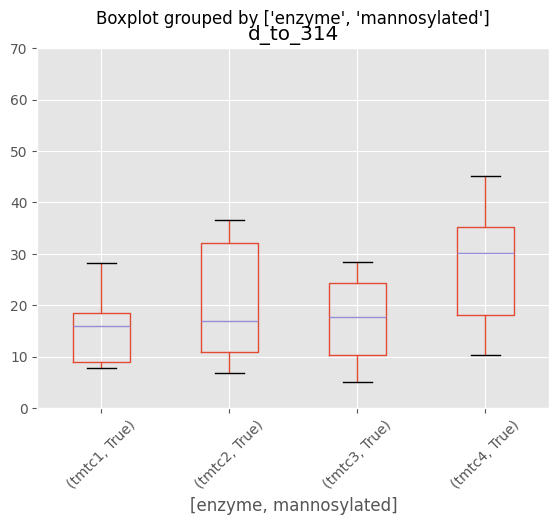

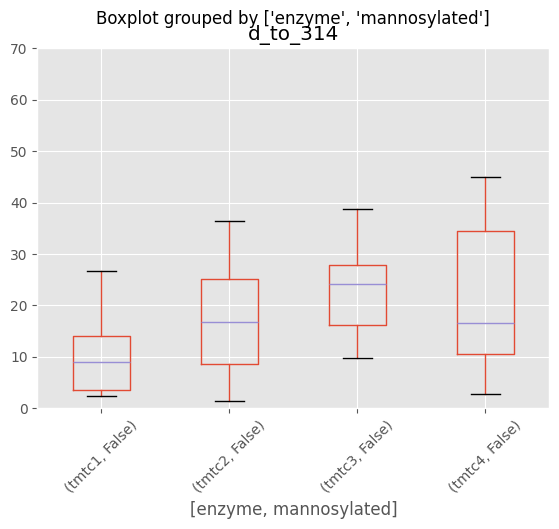

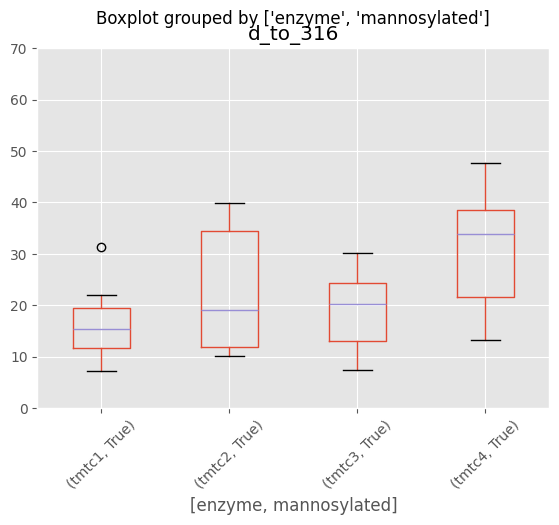

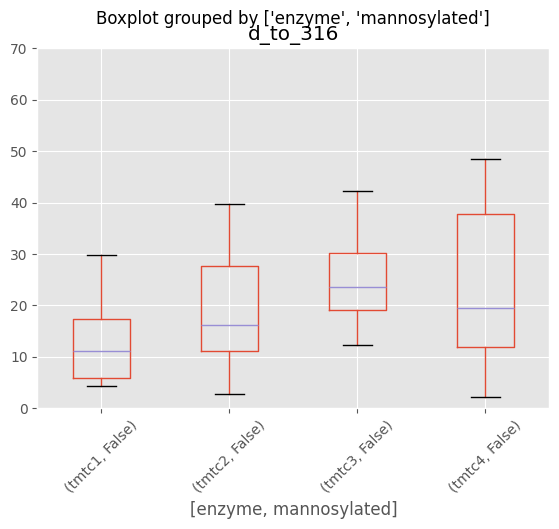

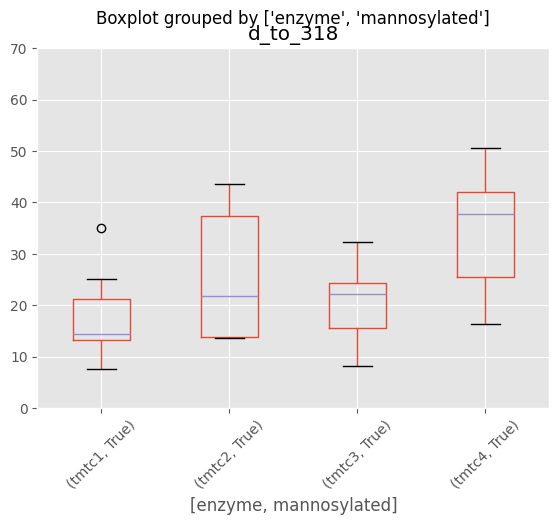

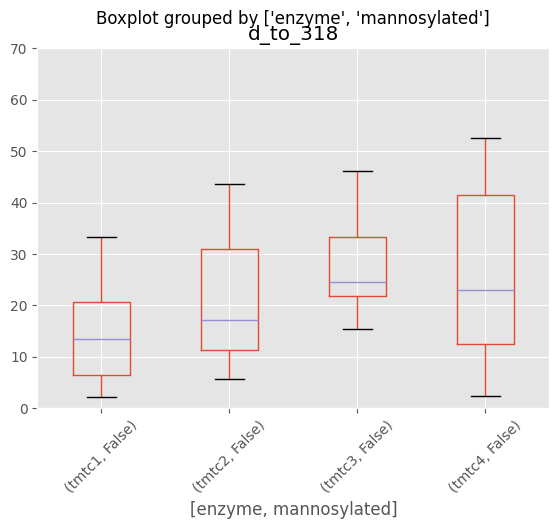

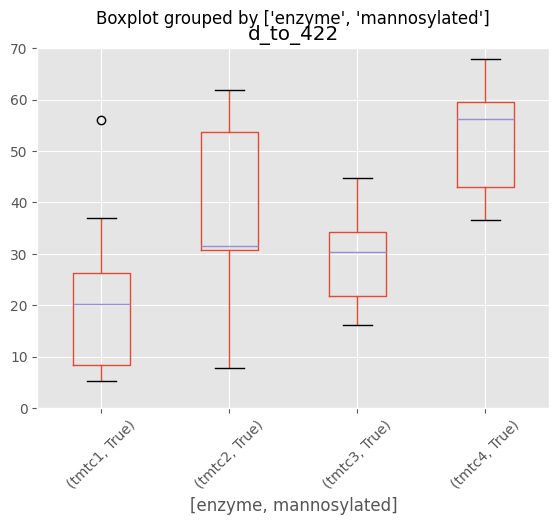

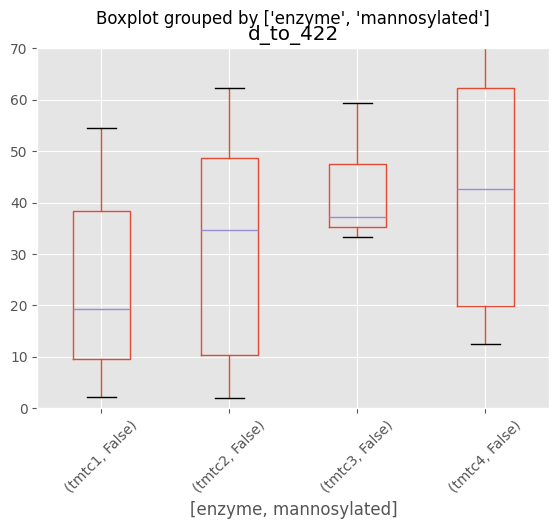

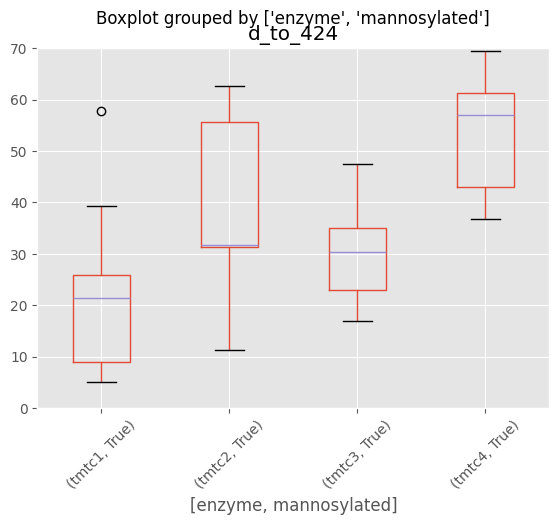

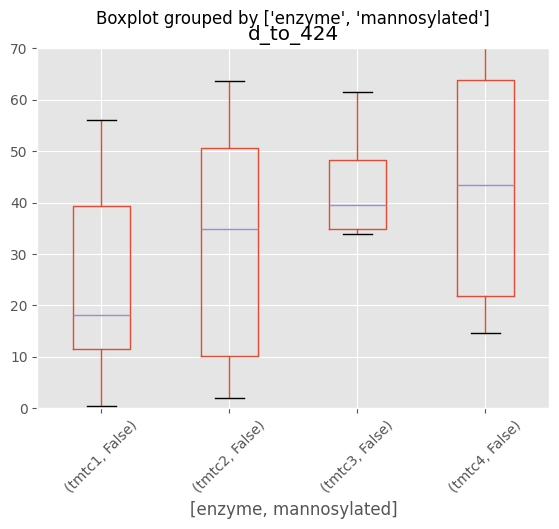

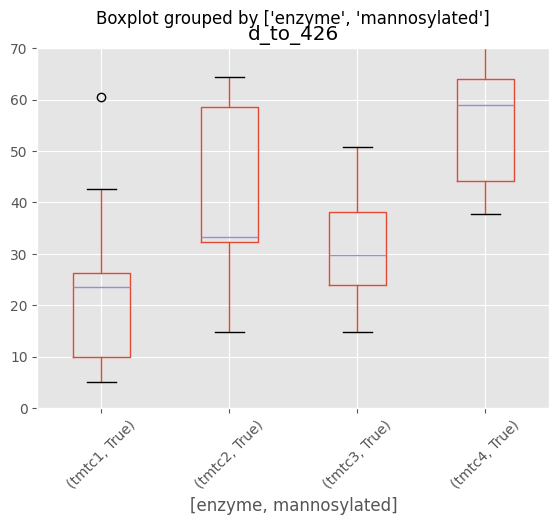

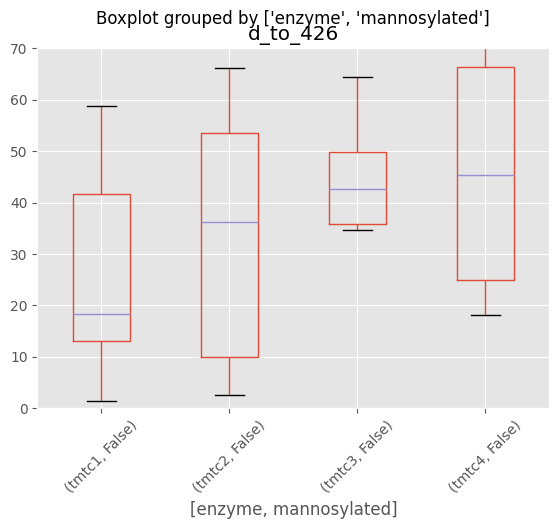

In [53]:
import matplotlib.pyplot as plt

plt.style.use(style="ggplot")

for mannose in [126,204,206,314,316,318,422,424,426]:
    
    bigbig_df[bigbig_df["mannosylated"]==True].boxplot(f"d_to_{mannose}",by=["enzyme","mannosylated"],rot=45)
    plt.ylim(0,70)
    bigbig_df[bigbig_df["mannosylated"]==False].boxplot(f"d_to_{mannose}",by=["enzyme","mannosylated"],rot=45)
    plt.ylim(0,70)


<Axes: title={'center': 'A-B RMSD'}, ylabel='[enzyme, model, mannosylated]'>

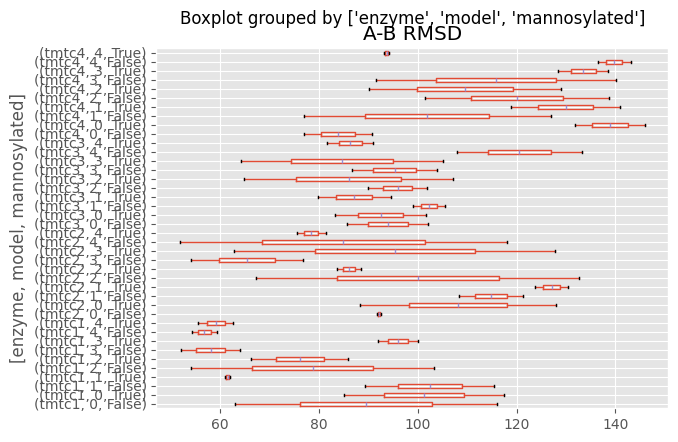

In [54]:
#bigdf.boxplot("iptm",by=["enzyme","mannosylated"],rot=45)
#bigdf.boxplot("plddt",by=["enzyme","mannosylated"],rot=45)
bigdf.boxplot("A-B RMSD",by=["enzyme","model","mannosylated"],vert=False)


In [57]:
from functions.Sliding_Functions import local_rmsd_plotter
import matplotlib.pyplot as plt

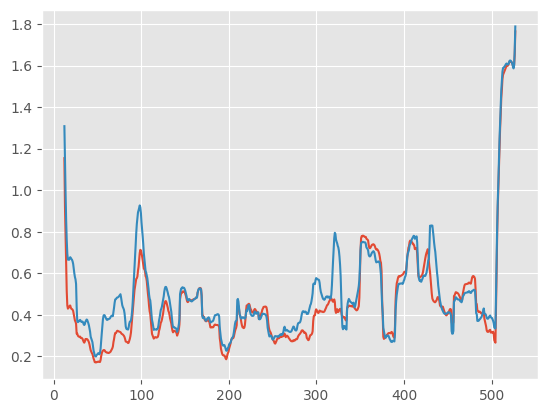

In [58]:
from numpy import array 
for i in ["fold_complex_tmtc1_model_3.cif","fold_complex_tmtc1_noptm_model_0.cif"]:
    x,y,plddt = local_rmsd_plotter(xr_df,grouped_model_list[i],2,75)
    plt.plot(array(x)/3,y)

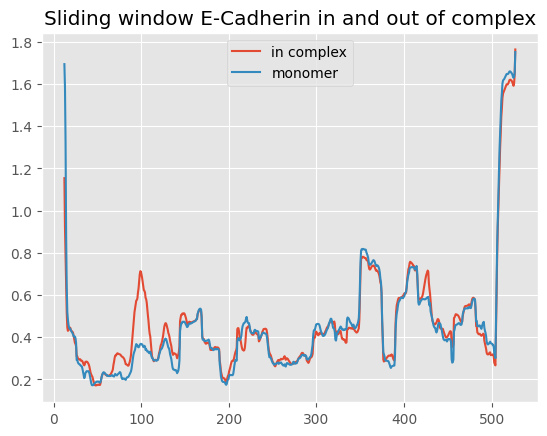

In [59]:
ptm_complex_df = make_df_atomlist("C:/Users/maxvV/Desktop/AF_Internship/Clean/notebooks/cif_files/Predictions/Complexes/fold_complex_tmtc1/fold_complex_tmtc1_model_3.cif",atomlist)
x,y1,plddt = local_rmsd_plotter(xr_df,ptm_complex_df,2,75)
plt.plot(array(x)/3,y1,label="in complex")
ptm_df = make_df_atomlist("C:/Users/maxvV/Desktop/AF_Internship/Clean/notebooks/cif_files/Predictions/SEEDMATCHED/fold_adnan_seed42_ptms/fold_adnan_seed42_ptms_model_3.cif",atomlist)
x,y,plddt = local_rmsd_plotter(xr_df,ptm_df,2,75)
plt.plot(array(x)/3,y,label="monomer")
plt.legend(); plt.title("Sliding window E-Cadherin in and out of complex");


In [72]:
from functions.cleaning_functions import dist
def interacting(complex_path,cutoff):

    df = make_df_full(complex_path)
    interacting = 0
    b_coords = df[(df["label_asym_id"]=="B")&(df["label_atom_id"]=="CA")][["Cartn_x","Cartn_y","Cartn_z"]].values.astype(float)
    a_coords = df[(df["label_asym_id"]=="A")&(df["label_atom_id"]=="CA")][["Cartn_x","Cartn_y","Cartn_z"]].values.astype(float)
    for b in b_coords:
        for a in a_coords:
            ds = dist(b,a)
            if ds <cutoff:
                interacting+=1
    return interacting

def interacting_fast(complex_path, cutoff):
    df = make_df_full(complex_path)
    
    # Extract coordinates of CA atoms from chains A and B
    b_coords = df[(df["label_asym_id"] == "B") & (df["label_atom_id"] == "CA")][["Cartn_x", "Cartn_y", "Cartn_z"]].values.astype(float)
    a_coords = df[(df["label_asym_id"] == "A") & (df["label_atom_id"] == "CA")][["Cartn_x", "Cartn_y", "Cartn_z"]].values.astype(float)
    
    # Vectorized pairwise distance calculation
    diff = a_coords[:, np.newaxis, :] - b_coords[np.newaxis, :, :]  # shape: (m, n, 3)
    dists = np.linalg.norm(diff, axis=2)                            # shape: (m, n)

    # Count the number of distances below the cutoff
    interacting_count = np.sum(dists < cutoff)
    
    return int(interacting_count)

def min_distance_slow(complex_path, all_atoms = False):

    df = make_df_full(complex_path)
    if all_atoms:
        b_coords = df[(df["label_asym_id"]=="B")][["Cartn_x","Cartn_y","Cartn_z"]].values.astype(float)
        a_coords = df[(df["label_asym_id"]=="A")][["Cartn_x","Cartn_y","Cartn_z"]].values.astype(float)
    else:
        b_coords = df[(df["label_asym_id"]=="B")&(df["label_atom_id"]=="CA")][["Cartn_x","Cartn_y","Cartn_z"]].values.astype(float)
        a_coords = df[(df["label_asym_id"]=="A")&(df["label_atom_id"]=="CA")][["Cartn_x","Cartn_y","Cartn_z"]].values.astype(float)
        
    ds_ = 100
    for b in b_coords:
        for a in a_coords:
            ds = dist(b,a)
            if ds <ds_:
                ds_ = ds
    return ds_

import numpy as np

def min_distance_fast(complex_path, all_atoms=False):
    df = make_df_full(complex_path)
    
    if all_atoms:
        b_coords = df[df["label_asym_id"] == "B"][["Cartn_x", "Cartn_y", "Cartn_z"]].values.astype(float)
        a_coords = df[df["label_asym_id"] == "A"][["Cartn_x", "Cartn_y", "Cartn_z"]].values.astype(float)
    else:
        b_coords = df[(df["label_asym_id"] == "B") & (df["label_atom_id"] == "CA")][["Cartn_x", "Cartn_y", "Cartn_z"]].values.astype(float)
        a_coords = df[(df["label_asym_id"] == "A") & (df["label_atom_id"] == "CA")][["Cartn_x", "Cartn_y", "Cartn_z"]].values.astype(float)
    
    # Efficient pairwise distance computation
    # a_coords: (m, 3), b_coords: (n, 3)
    # broadcasting to (m, n, 3) and computing squared distances
    diff = a_coords[:, np.newaxis, :] - b_coords[np.newaxis, :, :]
    dists = np.linalg.norm(diff, axis=2)
    
    return np.min(dists)

In [73]:
bigbig_df["smallest_distance"] = [min_distance_fast(path,all_atoms=True) for path in filepaths]
bigbig_df["interacting_CA"] = [interacting_fast(path,5) for path in filepaths]
bigbig_df["interacting_CA_8"] = [interacting_fast(path,8) for path in filepaths]

In [ ]:
# scorelist2 = pd.read_csv("interface_scores.txt",index_col=0)
# temp_df = bigbig_df.join(scorelist2)
# temp_df.boxplot("Scorelist2",by=["enzyme","model"],vert=False)

FileNotFoundError: [Errno 2] No such file or directory: 'interface_scores.txt'

In [76]:
def interacting_pairs_fast(complex_path, cutoff, all_atoms=False):

    df = make_df_full(complex_path)

    if all_atoms:
        a_df = df[df["label_asym_id"] == "A"]
        b_df = df[df["label_asym_id"] == "B"]
    else:
        mask = df["label_atom_id"].isin(["CA", "N", "C"])
        a_df = df[(df["label_asym_id"] == "A") & mask]
        b_df = df[(df["label_asym_id"] == "B") & mask]

    a_coords = a_df[["Cartn_x", "Cartn_y", "Cartn_z"]].values.astype(float)
    a_atoms  = a_df["label_atom_id"].values
    a_ids    = a_df["auth_seq_id"].astype(str) + "_" + a_df["label_atom_id"]
    
    b_coords = b_df[["Cartn_x", "Cartn_y", "Cartn_z"]].values.astype(float)
    b_atoms  = b_df["label_atom_id"].values
    b_ids    = b_df["auth_seq_id"].astype(str) + "_" + b_df["label_atom_id"]

    # Compute all pairwise distances
    diff = a_coords[:, np.newaxis, :] - b_coords[np.newaxis, :, :]
    dists = np.linalg.norm(diff, axis=2)

    # Find all pairs below the cutoff
    close_mask = dists < cutoff
    a_indices, b_indices = np.where(close_mask)

    score = 0
    pair_distances = {}

    for ai, bi in zip(a_indices, b_indices):
        atom_a = a_atoms[ai]
        atom_b = b_atoms[bi]
        pair_type = ''.join(sorted([atom_a[0], atom_b[0]]))  # First letter only

        # Scoring
        if pair_type in {"CN", "CO"}:
            score -= 1
        else:
            score += 1

        # Dictionary key and distance
        key = f"{a_ids.iloc[ai]} to {b_ids.iloc[bi]}"
        pair_distances[key] = dists[ai, bi]

    return score, pair_distances

bigbig_df["scorelist_fast"] = [interacting_pairs_fast(filepath,5,all_atoms=True)[0] for filepath in filepaths]

<Axes: title={'center': 'scorelist_fast'}, ylabel='[enzyme, model]'>

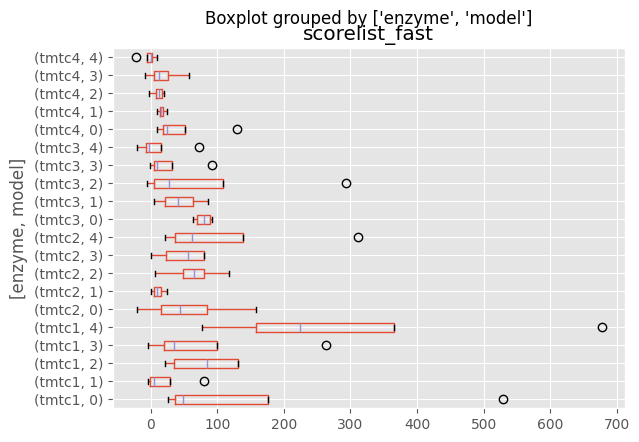

In [77]:
bigbig_df.boxplot("scorelist_fast",by=["enzyme","model"],vert=False)

In [79]:
bigbig_df[40:].head()

,enzyme,model,plddt,mannosylated,seed,iptm,ptm,zinkRMSD,A-B RMSD,fullname,...,d_to_316,d_to_318,d_to_422,d_to_424,d_to_426,scorelist_fast,PAE hist,smallest_distance,interacting_CA,interacting_CA_8
40,tmtc1,0,88.736346,True,auto,0.28,0.45,15.681703,117.389588,fold_complex_tmtc1_auto_model_0.cif,...,31.383255,34.960741,55.991455,57.826380,60.529560,26,"[30.83225371120112, 30.774358974358968, 30.706...",0.846439,6,90
41,tmtc1,1,88.939160,True,auto,0.27,0.46,17.846003,61.047423,fold_complex_tmtc1_auto_model_1.cif,...,15.154266,13.155120,5.773474,6.978525,9.140187,0,"[31.587314439945892, 31.60256410256387, 31.591...",2.815980,1,8
42,tmtc1,2,88.779728,True,auto,0.27,0.47,19.190719,66.377108,fold_complex_tmtc1_auto_model_2.cif,...,7.231275,7.658718,15.051911,18.819542,22.039943,22,"[31.555600539811014, 31.556410256410157, 31.54...",2.278719,0,10
43,tmtc1,3,87.261821,True,auto,0.27,0.44,17.088919,100.023003,fold_complex_tmtc1_auto_model_3.cif,...,16.520765,18.430753,36.944025,39.357121,42.597920,264,"[30.60040485829956, 30.451551956815088, 30.452...",0.365833,61,437
44,tmtc1,4,87.653840,True,auto,0.27,0.45,91.036167,62.747735,fold_complex_tmtc1_auto_model_4.cif,...,11.808462,14.175081,24.165657,24.428637,26.071116,261,"[30.826990553306377, 30.67543859649119, 30.607...",0.363264,46,325


# PAE

In [80]:
import json
import matplotlib.pyplot as plt
filepaths_full= glob.glob('cif_files\\Predictions\\Complexes\\*tmtc[1-4]\\*full_*.json')
filepaths_full.extend(glob.glob('cif_files\\Predictions\\Complexes\\*noptm\\*ull_*.json'))
filepaths_full.extend(glob.glob('cif_files\\Predictions\\Complexes\\Auto_seed\\*[1-4]_auto\\*ull_*.json'))
filepaths_full.extend(glob.glob('cif_files\\Predictions\\Complexes\\Auto_seed\\*noptm_auto\\*ull_*.json'))


In [81]:
min_distance_fast(filepaths[40],all_atoms=True)
filepaths[10:15]

['cif_files\\Predictions\\Complexes\\fold_complex_tmtc3\\fold_complex_tmtc3_model_0.cif',
 'cif_files\\Predictions\\Complexes\\fold_complex_tmtc3\\fold_complex_tmtc3_model_1.cif',
 'cif_files\\Predictions\\Complexes\\fold_complex_tmtc3\\fold_complex_tmtc3_model_2.cif',
 'cif_files\\Predictions\\Complexes\\fold_complex_tmtc3\\fold_complex_tmtc3_model_3.cif',
 'cif_files\\Predictions\\Complexes\\fold_complex_tmtc3\\fold_complex_tmtc3_model_4.cif']

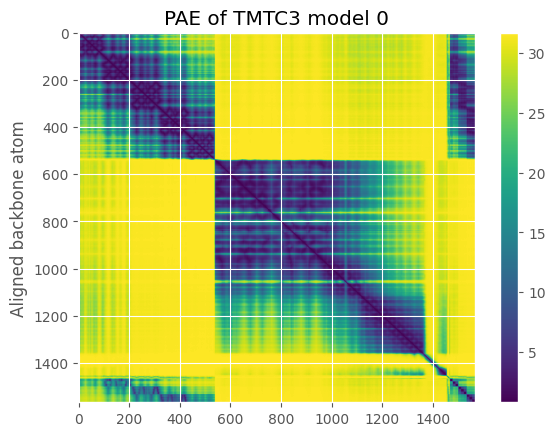

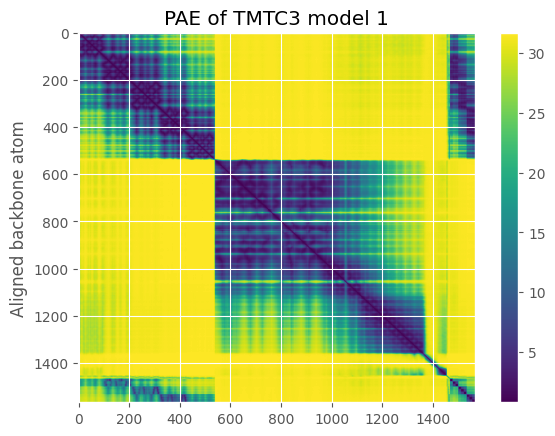

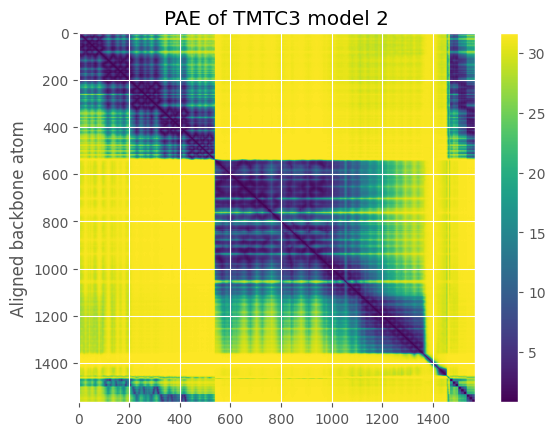

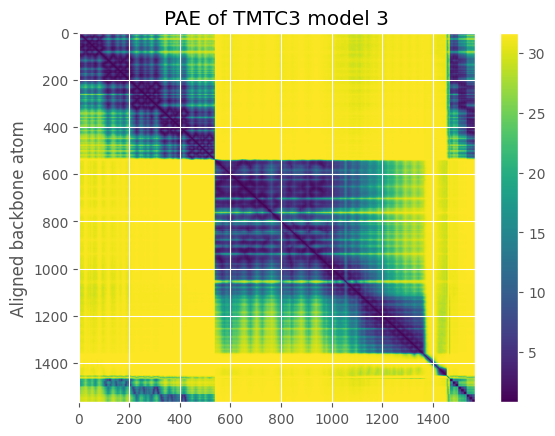

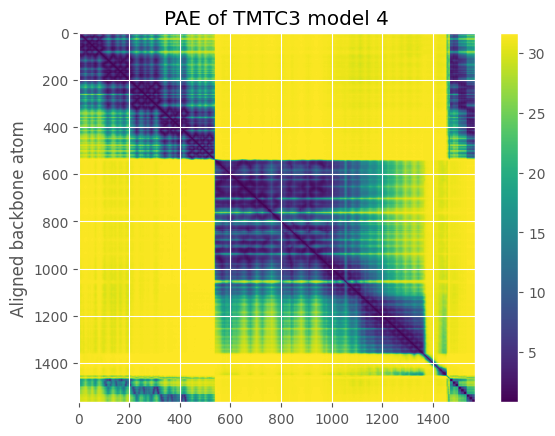

In [82]:
for i in range(10,15):
    plt.imshow(json.load(open(filepaths_full[i]))["pae"],aspect="auto")
    plt.colorbar()
    plt.title(f"PAE of TMTC3 model {i-10}")
    plt.ylabel("Aligned backbone atom")
    plt.show()

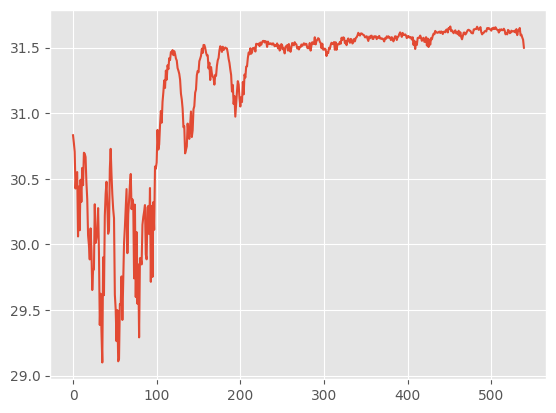

In [67]:
matrix = json.load(open(filepaths_full[40]))["pae"]
#sub_matrix = [matrix[i][(540):(540+741)] for i in range(540)]
sub_matrix = [matrix[i][:540] for i in range((540),(540+741))]

plt.plot(np.average(sub_matrix, axis=0))

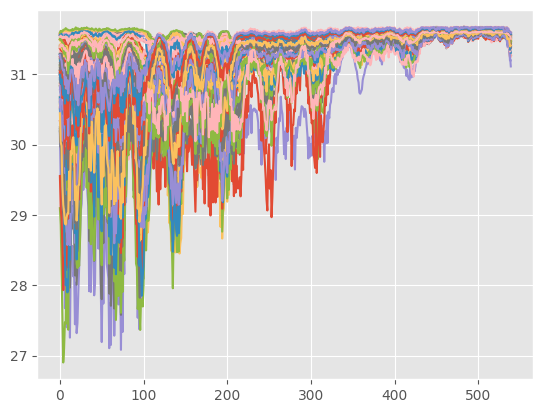

In [68]:
for filepath in filepaths_full:
    matrix = json.load(open(filepath))["pae"]
    #sub_matrix = [matrix[i][(540):(540+741)] for i in range(540)]
    sub_matrix = [matrix[i][:540] for i in range((540),(540+741))]

    plt.plot(np.average(sub_matrix, axis=0))

In [39]:
pae_sum_list = []
for filepath in filepaths_full:
    matrix = json.load(open(filepath))["pae"]
    #sub_matrix = [matrix[i][(540):(540+741)] for i in range(540)]
    sub_matrix = [matrix[i][:540] for i in range((540),(540+741))]

    pae_sum_list.append(np.mean(sub_matrix, axis=0))

In [32]:
#   TMTC1-3 affect the G-strand:
#   so should be close to res: [204,206,314,316,318,422 424 426]
#   By elimination then TMTC2-4: [126]

Text(0.5, 1.0, 'Average PAE per enzyme')

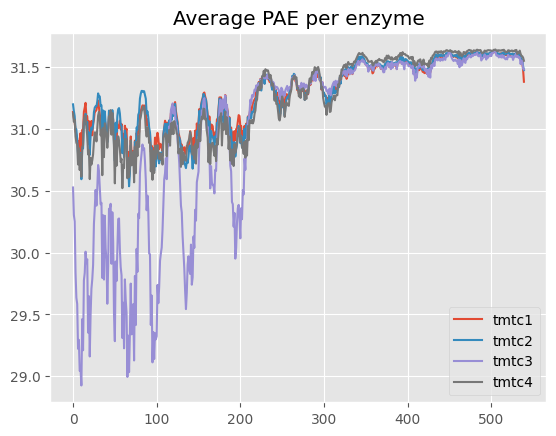

In [69]:
bigbig_df["PAE hist"] = pae_sum_list
# mean- show 95confidence interval
for enzyme,summed_hist in bigbig_df.groupby("enzyme")["PAE hist"].apply(np.mean).items():
    plt.plot(summed_hist, label=enzyme)
plt.legend()
plt.title("Average PAE per enzyme")

In [70]:
bigbig_df

,enzyme,model,plddt,mannosylated,seed,iptm,ptm,zinkRMSD,A-B RMSD,fullname,...,d_to_204,d_to_206,d_to_314,d_to_316,d_to_318,d_to_422,d_to_424,d_to_426,scorelist_fast,PAE hist
0,tmtc1,0,88.214494,True,37,0.28,0.47,17.862681,85.155961,fold_complex_tmtc1_model_0.cif,...,14.158014,10.197174,8.539570,11.515374,13.156400,6.283568,5.095018,5.001271,58,"[31.575033738191816, 31.59203778677464, 31.583..."
1,tmtc1,1,88.430710,True,37,0.27,0.47,84.671460,62.108678,fold_complex_tmtc1_model_1.cif,...,8.213763,7.284896,19.037940,21.921391,25.158004,26.925064,26.237109,26.282768,11,"[30.946288798920374, 30.796221322537072, 30.78..."
2,tmtc1,2,87.687611,True,37,0.27,0.48,17.857156,85.896233,fold_complex_tmtc1_model_2.cif,...,6.274461,5.858767,19.730770,20.446456,22.066662,24.051720,23.807273,24.880974,131,"[31.249527665317107, 31.19622132253706, 31.266..."
3,tmtc1,3,88.497827,True,37,0.28,0.47,19.429389,91.934868,fold_complex_tmtc1_model_3.cif,...,14.565470,11.703496,16.808941,15.631783,14.620201,5.261194,7.162960,8.562589,-4,"[31.560728744939194, 31.611336032388415, 31.58..."
4,tmtc1,4,87.958469,True,37,0.27,0.48,18.274394,55.609018,fold_complex_tmtc1_model_4.cif,...,8.400137,9.766837,7.725962,8.726123,10.434560,16.259455,14.257870,12.478342,77,"[30.62429149797566, 30.54251012145751, 30.3842..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,tmtc4,0,88.510259,False,auto,0.14,0.53,14.887019,77.044763,fold_complex_tmtc4_noptm_auto_model_0.cif,...,9.606692,6.550498,12.206246,11.609633,11.159647,12.552459,14.701272,18.102291,26,"[31.388529014844714, 31.414439946018994, 31.40..."
76,tmtc4,1,88.438475,False,auto,0.14,0.53,73.920072,76.965346,fold_complex_tmtc4_noptm_auto_model_1.cif,...,10.220356,7.136084,10.292988,11.062075,11.331648,14.568542,17.271513,20.913771,24,"[31.38151147098509, 31.42091767881256, 31.4020..."
77,tmtc4,2,89.286716,False,auto,0.13,0.53,128.519921,138.684876,fold_complex_tmtc4_noptm_auto_model_2.cif,...,18.009481,21.093860,44.277447,46.702365,49.660532,66.684555,68.680573,71.664378,11,"[31.035762483130952, 30.86180836707157, 30.911..."
78,tmtc4,3,89.571432,False,auto,0.13,0.53,15.749740,140.123489,fold_complex_tmtc4_noptm_auto_model_3.cif,...,24.018380,27.571845,44.980976,48.568828,52.477520,71.997237,72.750205,74.629894,9,"[30.992442645074256, 30.865721997300984, 30.92..."


10
10
10
10


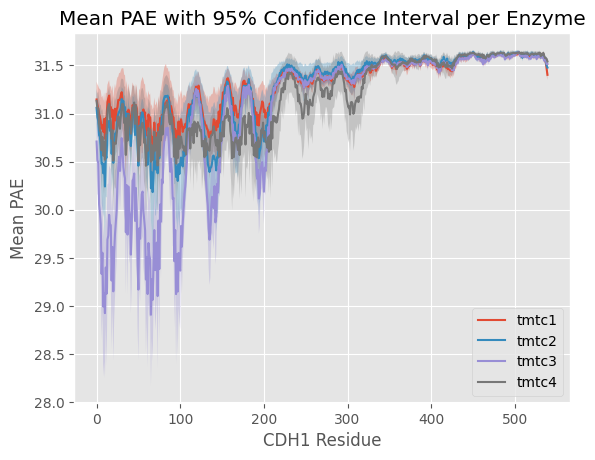

In [71]:
# Get unique enzymes
enzymes = bigbig_df["enzyme"].unique()

for enzyme in enzymes:
    # Extract all histograms for the current enzyme
    hist_list = bigbig_df[(bigbig_df["enzyme"] == enzyme)&(bigbig_df["seed"] == 37)]["PAE hist"].tolist()
    
    # Stack into a 2D array: rows = samples, cols = histogram bins
    hist_array = np.vstack(hist_list)  # shape: (n_samples, n_bins)
    print(len(hist_array))
    # Compute mean and 95% confidence interval
    mean_hist = np.mean(hist_array, axis=0)
    sem_hist = np.std(hist_array, axis=0, ddof=1) / np.sqrt(hist_array.shape[0])
    ci95_upper = mean_hist + 1.96 * sem_hist
    ci95_lower = mean_hist - 1.96 * sem_hist

    # Plot mean line
    plt.plot(mean_hist, label=enzyme)

    # Fill between for 95% CI
    plt.fill_between(range(len(mean_hist)), ci95_lower, ci95_upper, alpha=0.3)

plt.legend()
plt.xlabel("CDH1 Residue")
plt.ylabel("Mean PAE")
plt.title("Mean PAE with 95% Confidence Interval per Enzyme")
plt.show()


In [35]:
#ab = []
#ba = []
#ba1 = []
#ba2 = []
#ba3 = []
#
#for filepath in filepaths_full:
#    matrix = json.load(open(filepath))["pae"]
#    ab.append(np.average([matrix[i][(540):(540+741)] for i in range(540)])) # middletop
#    ba.append(np.average([matrix[i][:540] for i in range((540),(540+741))])) # middleleft
#    ba1.append(np.average([matrix[i][:99] for i in range((540),(540+741))])) # middleleft_EC1
#    ba2.append(np.average([matrix[i][113:212] for i in range((540),(540+741))])) # middleleft_EC2
#    ba3.append(np.average([matrix[i][226:324] for i in range((540),(540+741))])) # middleleft_EC2
#bigbig_df["AVG pae ab"] = ab
#bigbig_df["AVG pae ba"] = ba
#bigbig_df["AVG pae ba EC1"] = ba1
#bigbig_df["AVG pae ba EC2"] = ba2
#bigbig_df["AVG pae ba EC3"] = ba3

In [36]:
all_points = []
for filepath in filepaths_full:
    matrix = json.load(open(filepath))["pae"]
    sub_matrix = [matrix[i][:540] for i in range((540),(540+741))]
    all_points.append(array(sub_matrix).flatten())
bigbig_df["PAE all_points"] = all_points

bigbig_df["ipTM+pTM"] = (.8*bigbig_df["iptm"]) +  (.2*bigbig_df["ptm"])
bigbig_df["summarized_score"] = bigbig_df["ipTM+pTM"] + bigbig_df["iptm"] + bigbig_df["ptm"] + bigbig_df["plddt"]/100 

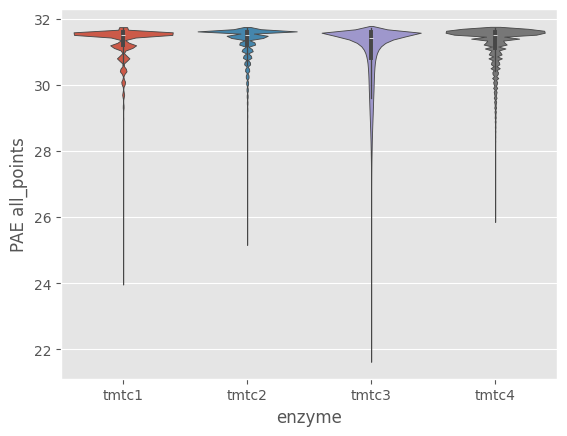

In [37]:
#bigbig_df.boxplot("PAE all_points",by="enzyme")
exploded_df = bigbig_df.explode("PAE all_points")

# Now you can boxplot
#exploded_df.boxplot(column="PAE all_points", by="enzyme")
sns.violinplot(data=exploded_df,y="PAE all_points",x="enzyme",hue="enzyme");

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x0000013A0D55DCD0>>
Traceback (most recent call last):
  File "C:\Users\maxvV\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\ipykernel\ipkernel.py", line 790, in _clean_thread_parent_frames
    active_threads = {thread.ident for thread in threading.enumerate()}
                                                 ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\threading.py", line 1501, in enumerate
    def enumerate():
    
KeyboardInterrupt: 


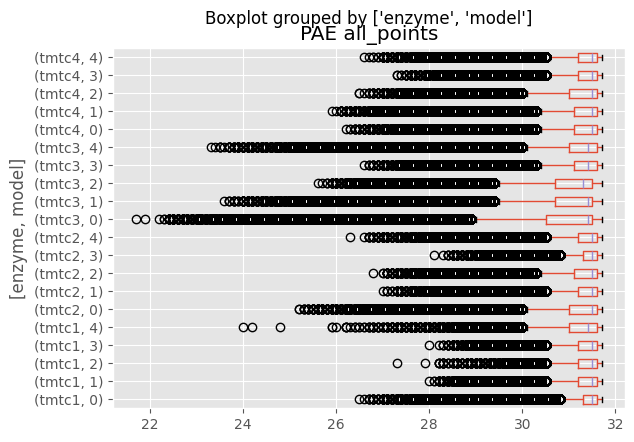

In [38]:
exploded_df.boxplot(column="PAE all_points", by=["enzyme","model"],vert=False);

<Axes: title={'center': 'ipTM+pTM'}, ylabel='[mannosylated, model, seed]'>

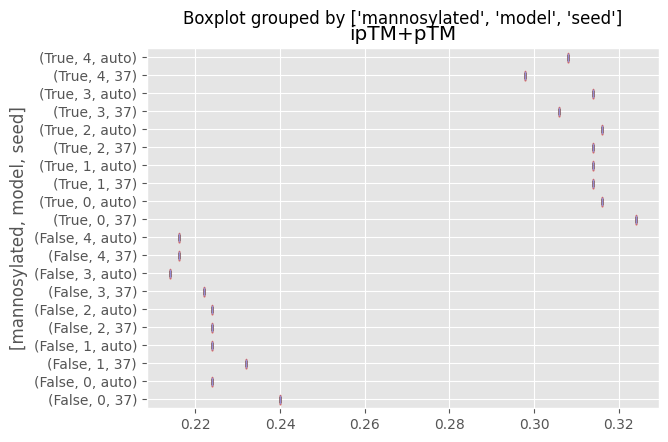

In [ ]:
#bigbig_df[bigbig_df["enzyme"]=="tmtc3"].sort_values("summarized_score",ascending=False)
bigbig_df[bigbig_df["enzyme"]=="tmtc3"].boxplot("ipTM+pTM",by=["mannosylated","model","seed"],vert=False)

In [ ]:
bigbig_df.to_csv("bigbig_df.txt")